## MDI3003 - Experiment 08: Agricultural Predictive Analytics
### Crop Yield Prediction with Guided District-Level Analytics
* Group 1: Environment Setup, Configuration, and Directory Architecture
* Group 2: Data Ingestion, Unit Harmonization, and Canonical Dataset Generation
* Group 3: Temporal Splitting, Whitelist Enforcement, and Training EDA
* Group 4: Preprocessing Pipelines, Candidate Benchmarking, and Rolling Origins
* Group 5: Model Selection and Single-Pass Locked-Test Evaluation
* Group 6: Error Diagnostics, Bundle Serialization, and Colab Download
* Output Artifact Summary

### Group 1: Environment Setup, Configuration, and Directory Architecture

This step installs the required spreadsheet parsing dependencies in Google Colab, initializes directory structures (`data/`, `outputs/core/`, `models/`, `figures/`, `artifacts/`), seeds random generators for reproducibility, and defines the Experiment 08 prediction contract. The contract explicitly fixes the target unit to tonnes per hectare ($t/\text{ha}$) and whitelists only pre-harvest features (state, district, season, year).

In [1]:
# ==============================================================================
# GROUP 1: SETUP, DIRECTORY ARCHITECTURE, AND CONFIGURATION CONTRACT
# ==============================================================================
import os
import sys
import json
import hashlib
import platform
from pathlib import Path

# Install Excel engine dependencies if running in Colab
!pip install -q xlrd openpyxl scikit-learn pandas numpy matplotlib joblib

import numpy as np
import pandas as pd
import sklearn
import joblib
import matplotlib.pyplot as plt

# Configuration parameters aligned with MD13003 Experiment 08 specifications
REG_NO = "REG_NO_2026"  # Replace with your registration number
SEED = 42

BASE_DIR = Path("./")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs" / "core"
MODELS_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = OUTPUT_DIR / "figures"
ARTIFACTS_DIR = OUTPUT_DIR / "artifacts"

for folder in [DATA_DIR, OUTPUT_DIR, MODELS_DIR, FIGURES_DIR, ARTIFACTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Define prediction contract
CONFIG = {
    "task": "regression",
    "crop": "Rice",
    "yield_unit": "t/ha",
    "advanced": False,
    "seed": SEED,
    "raw_data_filename": "main merge (droped _merge==2) (560 dist 1990-2015).xls",
    "canonical_path": str(DATA_DIR / "rice_canonical.csv"),
    "output_dir": str(OUTPUT_DIR),
    "features_whitelist": ["state", "district", "season", "year"],
    "target": "yield_t_ha",
    "registration_no": REG_NO
}

with open(ARTIFACTS_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Directory structure created successfully.")
print(f"Active Environment: Python {platform.python_version()} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

Directory structure created successfully.
Active Environment: Python 3.13.15 | scikit-learn 1.6.1 | pandas 2.2.3


### Group 2: Data Ingestion, Unit Harmonization, and Canonical Dataset Generation

This step audits the raw ICRISAT panel dataset (`main merge (droped _merge==2) (560 dist 1990-2015).xls`). It standardizes column headers, extracts the geographical spatial keys (state, district), standardizes temporal indices (year), harmonizes Rice yield to metric tonnes per hectare ($t/\text{ha}$), assigns season='Annual', removes non-positive/missing targets, and saves the immutable canonical dataset `data/rice_canonical.csv` with SHA-256 hash logging.

In [2]:
# ==============================================================================
# GROUP 2: INGESTION, UNIT HARMONIZATION, AND CANONICAL CSV EXPORT
# ==============================================================================
import re

raw_file_candidate = Path(CONFIG["raw_data_filename"])
if not raw_file_candidate.exists():
    matches = list(Path(".").glob("*.xls*"))
    if matches:
        raw_file_candidate = matches[0]
        print(f"Discovered input spreadsheet: {raw_file_candidate}")
    else:
        raise FileNotFoundError(
            f"Please upload '{CONFIG["raw_data_filename"]}' into the Colab root directory."
        )

print(f"Reading {raw_file_candidate}...")
xls_file = pd.ExcelFile(raw_file_candidate)
raw_df = pd.read_excel(raw_file_candidate, sheet_name=xls_file.sheet_names[0])
print(f"Raw file shape: {raw_df.shape}")

# Normalize column names: trim and uppercase
normalized_cols = {c: str(c).strip().upper() for c in raw_df.columns}
raw_df = raw_df.rename(columns=normalized_cols)

# Resolve State, District, and Year columns dynamically
def find_col(pattern_list, columns):
    for pat in pattern_list:
        match = [c for c in columns if re.search(pat, c, re.IGNORECASE)]
        if match:
            return match[0]
    return None

state_col = find_col([r"^STNAME$", r"^STATE\s*NAME$", r"^STATE$"], raw_df.columns)
dist_col = find_col([r"^DISTNAME$", r"^DIST\s*NAME$", r"^DISTRICT$"], raw_df.columns)
year_col = find_col([r"^YEAR$"], raw_df.columns)

yield_col = find_col([r"RICE.*YIELD.*KG", r"RICE.*YIELD"], raw_df.columns)
prod_col = find_col([r"RICE.*PRODUCTION", r"RICE.*PROD"], raw_df.columns)
area_col = find_col([r"RICE.*AREA"], raw_df.columns)

if not (state_col and dist_col and year_col):
    raise KeyError(f"Identifier columns not found. Detected: {raw_df.columns[:8].tolist()}")

# Create standardized working subset
clean_df = pd.DataFrame()
clean_df["state"] = raw_df[state_col].astype(str).str.strip().str.title()
clean_df["district"] = raw_df[dist_col].astype(str).str.strip().str.title()
clean_df["year"] = pd.to_numeric(raw_df[year_col], errors="coerce")
clean_df["crop"] = "Rice"
clean_df["season"] = "Annual"

# Yield derivation and unit validation (Must be t/ha)
if yield_col:
    print(f"Using reported yield column: '{yield_col}'")
    raw_yield = pd.to_numeric(raw_df[yield_col], errors="coerce")
    # If reported in kg/ha, convert to t/ha: 1 t/ha = 1000 kg/ha
    if "KG" in yield_col.upper():
        clean_df["yield_t_ha"] = raw_yield / 1000.0
    else:
        clean_df["yield_t_ha"] = raw_yield
elif prod_col and area_col:
    print(f"Deriving yield from '{prod_col}' and '{area_col}'")
    p = pd.to_numeric(raw_df[prod_col], errors="coerce")
    a = pd.to_numeric(raw_df[area_col], errors="coerce")
    clean_df["yield_t_ha"] = np.where(a > 0, p / a, np.nan)
else:
    raise ValueError("Neither Rice Yield nor Rice Area/Production pairs found.")

# Filter missing values, infinite targets, non-positive yields, and invalid years
initial_len = len(clean_df)
clean_df = clean_df.dropna(subset=["state", "district", "year", "yield_t_ha"])
clean_df = clean_df[clean_df["year"] == clean_df["year"].astype(int)]
clean_df["year"] = clean_df["year"].astype(int)
clean_df = clean_df[np.isfinite(clean_df["yield_t_ha"]) & (clean_df["yield_t_ha"] > 0)]

# Drop conflicting repeated district-season-year keys
key_cols = ["state", "district", "season", "year"]
clean_df = clean_df.drop_duplicates(subset=key_cols, keep="first")
clean_df = clean_df.sort_values(["year", "state", "district"]).reset_index(drop=True)
clean_df["row_id"] = [f"RICE_{idx+1:06d}" for idx in range(len(clean_df))]

# Reorder columns explicitly according to canonical specification
canonical_cols = ["row_id", "crop", "state", "district", "season", "year", "yield_t_ha"]
clean_df = clean_df[canonical_cols]

# Save canonical dataset and generate hash
canonical_csv_path = Path(CONFIG["canonical_path"])
clean_df.to_csv(canonical_csv_path, index=False)
raw_hash = hashlib.sha256(raw_file_candidate.read_bytes()).hexdigest()
canonical_hash = hashlib.sha256(canonical_csv_path.read_bytes()).hexdigest()

audit_manifest = {
    "raw_file": str(raw_file_candidate),
    "raw_sha256": raw_hash,
    "canonical_sha256": canonical_hash,
    "raw_row_count": int(initial_len),
    "canonical_row_count": int(len(clean_df)),
    "unique_states": int(clean_df["state"].nunique()),
    "unique_districts": int(clean_df["district"].nunique()),
    "year_range": [int(clean_df["year"].min()), int(clean_df["year"].max())]
}

with open(ARTIFACTS_DIR / "provenance.json", "w") as f:
    json.dump(audit_manifest, f, indent=2)

print("\n--- Canonical Dataset Manifest ---")
display(pd.DataFrame([audit_manifest]).T.rename(columns={0: "Metadata"}))
print("\nFirst 5 Canonical Observations:")
display(clean_df.head())

Reading main merge (droped _merge==2) (560 dist 1990-2015).xls...
Raw file shape: (12803, 107)
Using reported yield column: 'RICE YIELD (KG PER HA)'

--- Canonical Dataset Manifest ---


,Metadata
raw_file,main merge (droped _merge==2) (560 dist 1990-2...
raw_sha256,278f2351543318f8e83412511c1434793f0364ad8d3ae5...
canonical_sha256,484b508b28397b39bc29c4824ea495530e38cbc2848f2f...
raw_row_count,12803
canonical_row_count,11969
unique_states,20
unique_districts,536
year_range,"[1990, 2015]"



First 5 Canonical Observations:


,row_id,crop,state,district,season,year,yield_t_ha
0,RICE_000001,Rice,Andhra Pradesh,Anantapur,Annual,1990,2.262
1,RICE_000002,Rice,Andhra Pradesh,Chittoor,Annual,1990,2.555
2,RICE_000003,Rice,Andhra Pradesh,East Godavari,Annual,1990,1.966
3,RICE_000004,Rice,Andhra Pradesh,Guntur,Annual,1990,3.169
4,RICE_000005,Rice,Andhra Pradesh,Kadapa Ysr,Annual,1990,2.830


### Group 3: Temporal Splitting, Whitelist Enforcement, and Training EDA

This step enforces chronological train/validation/test splitting. The final two observed harvest years are partitioned as the locked test set, the preceding two years serve as the validation set, and all prior historical years form the training pool. Post-harvest fields (production, area) are excluded to avoid data leakage. Exploratory data analysis (EDA) plots are generated and saved using training data only to prevent lookahead contamination.

--- Temporal Split Allocation ---


,split,row_count,min_year,max_year,unique_districts
0,train,9933,1990,2011,530
1,validation,1022,2012,2013,508
2,test,1014,2014,2015,508


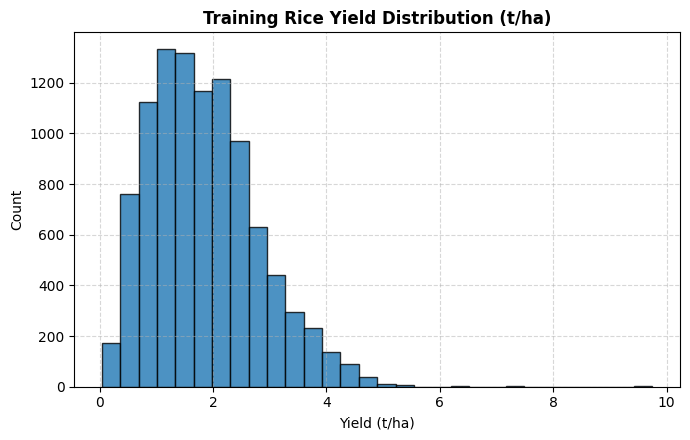

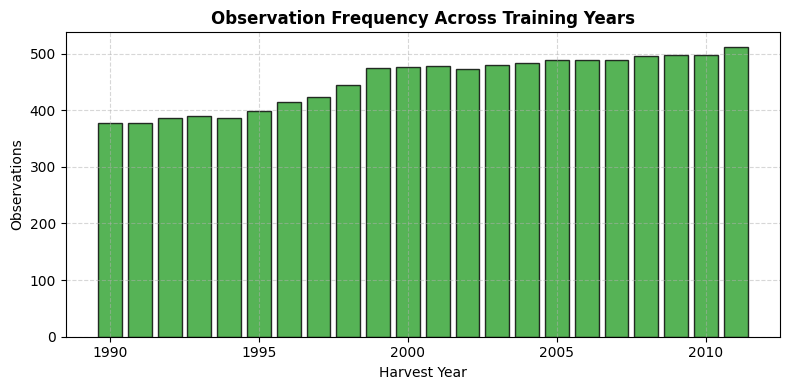

In [3]:
# ==============================================================================
# GROUP 3: TEMPORAL SPLITTING AND TRAINING-ONLY EDA
# ==============================================================================
df = pd.read_csv(CONFIG["canonical_path"])

# Verify chronological validity
years = sorted(df["year"].unique())
if len(years) < 7:
    raise ValueError(f"Requirement failed: At least 7 years required. Found: {len(years)}")

test_years = years[-2:]
val_years = years[-4:-2]
train_years = years[:-4]

df["split"] = "train"
df.loc[df["year"].isin(val_years), "split"] = "validation"
df.loc[df["year"].isin(test_years), "split"] = "test"

# Verify temporal split boundaries
assert df.loc[df.split == "train", "year"].max() < df.loc[df.split == "validation", "year"].min()
assert df.loc[df.split == "validation", "year"].max() < df.loc[df.split == "test", "year"].min()

# Export split manifest for audit trail
df[["row_id", "split"]].to_csv(ARTIFACTS_DIR / "split_manifest.csv", index=False)

split_summary = df.groupby("split").agg(
    row_count=("row_id", "count"),
    min_year=("year", "min"),
    max_year=("year", "max"),
    unique_districts=("district", "nunique")
).reindex(["train", "validation", "test"]).reset_index()

print("--- Temporal Split Allocation ---")
display(split_summary)

# Feature whitelist: Only pre-harvest location and time enter predictor matrix X
REG_FEATURES = ["state", "district", "season", "year"]
TARGET = "yield_t_ha"

train_df = df[df["split"] == "train"]

# EDA Plot 1: Target distribution on training data
plt.figure(figsize=(7, 4.5))
plt.hist(train_df[TARGET], bins=30, color="#1f77b4", edgecolor="black", alpha=0.8)
plt.title("Training Rice Yield Distribution (t/ha)", fontsize=12, fontweight="bold")
plt.xlabel("Yield (t/ha)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target.png", dpi=150)
plt.show()

# EDA Plot 2: Training year observation coverage
plt.figure(figsize=(8, 4))
year_counts = train_df["year"].value_counts().sort_index()
plt.bar(year_counts.index, year_counts.values, color="#2ca02c", edgecolor="black", alpha=0.8)
plt.title("Observation Frequency Across Training Years", fontsize=12, fontweight="bold")
plt.xlabel("Harvest Year")
plt.ylabel("Observations")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature.png", dpi=150)
plt.show()

### Group 4: Preprocessing Pipelines, Candidate Benchmarking, and Rolling Origins

This step builds preprocessing pipelines where categorical features are transformed using OneHotEncoder(handle_unknown='ignore') and continuous harvest years are scaled with StandardScaler. Preprocessing is strictly fitted on training splits. The code fits all four required models:
* Median Baseline: $\text{prediction} = \text{median}(y_{\text{train}})$
* Ridge Trend: $\alpha = 1.0$, solver='lsqr'
* Decision Tree: max_depth=6, min_samples_leaf=10
* Random Forest: n_estimators=60, max_depth=12, min_samples_leaf=5, n_jobs=2

It evaluates metrics ($\text{MAE}$, $\text{RMSE}$, $R^2$) on validation data, executes three one-year rolling origin cross-validations, and produces comparison.png.

--- Validation Results (Sorted by Primary Metric: MAE) ---


,model,seconds,MAE,RMSE,R2
1,ridge_trend,1.108674,0.449004,0.621276,0.596221
3,forest,27.022020,0.521885,0.691189,0.500232
2,tree,2.069198,0.705514,0.882221,0.185803
0,median,0.204113,0.888819,1.154991,-0.395508


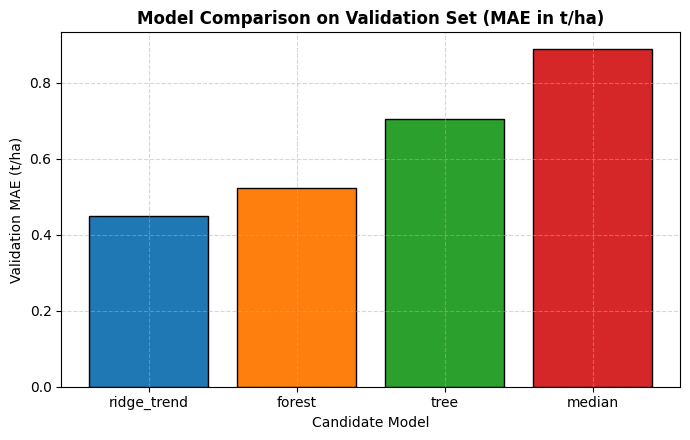

In [4]:
# ==============================================================================
# GROUP 4: PIPELINES, VALIDATION BENCHMARKING, AND ROLLING ORIGINS
# ==============================================================================
import time
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Metric helper functions
def compute_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 and np.ptp(np.asarray(y_true)) > 0 else float("nan")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# Define candidate model dictionary
def build_candidates():
    preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["state", "district", "season"]),
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), ["year"])
    ])

    models = {
        "median": DummyRegressor(strategy="median"),
        "ridge_trend": Ridge(alpha=1.0, solver="lsqr", random_state=SEED),
        "tree": DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=SEED),
        "forest": RandomForestRegressor(n_estimators=60, max_depth=12, min_samples_leaf=5, n_jobs=2, random_state=SEED)
    }

    return {name: Pipeline([("pre", clone(preprocessor)), ("model", model)]) for name, model in models.items()}

# Fit and evaluate candidate pipelines on validation set
train_sub = df[df["split"] == "train"]
val_sub = df[df["split"] == "validation"]

val_results = []
fitted_pipelines = {}

candidates = build_candidates()
for name, pipe in candidates.items():
    start_time = time.perf_counter()
    pipe.fit(train_sub[REG_FEATURES], train_sub[TARGET])
    runtime = time.perf_counter() - start_time

    val_preds = pipe.predict(val_sub[REG_FEATURES])
    metrics_dict = compute_regression_metrics(val_sub[TARGET], val_preds)

    val_results.append({
        "model": name,
        "seconds": runtime,
        **metrics_dict
    })

    fitted_pipelines[name] = pipe
    joblib.dump(pipe, MODELS_DIR / f"{name}.joblib")

# Three development-only rolling origins (stability diagnosis without test leakage)
development_df = df[df["split"] != "test"]
dev_origins = sorted(development_df["year"].unique())[-3:]
rolling_records = []

for origin in dev_origins:
    past = development_df[development_df["year"] < origin]
    future = development_df[development_df["year"] == origin]

    for name, pipe in build_candidates().items():
        pipe.fit(past[REG_FEATURES], past[TARGET])
        preds = pipe.predict(future[REG_FEATURES])
        m = compute_regression_metrics(future[TARGET], preds)
        rolling_records.append({
            "origin_year": int(origin),
            "model": name,
            "training_max_year": int(past["year"].max()),
            "eval_observations": len(future),
            **m
        })

rolling_df = pd.DataFrame(rolling_records)
rolling_df.to_csv(ARTIFACTS_DIR / "rolling_origins.csv", index=False)

# Format validation comparison table
val_results_df = pd.DataFrame(val_results).sort_values("MAE", ascending=True, kind="stable")
val_filename = OUTPUT_DIR / f"{REG_NO}_Lab08_Validation_Results.csv"
val_results_df.to_csv(val_filename, index=False)

print("--- Validation Results (Sorted by Primary Metric: MAE) ---")
display(val_results_df)

# Validation Bar Chart
plt.figure(figsize=(7, 4.5))
plt.bar(val_results_df["model"], val_results_df["MAE"], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"], edgecolor="black")
plt.title("Model Comparison on Validation Set (MAE in t/ha)", fontsize=12, fontweight="bold")
plt.xlabel("Candidate Model")
plt.ylabel("Validation MAE (t/ha)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison.png", dpi=150)
plt.show()

### Group 5: Model Selection and Single-Pass Locked-Test Evaluation

This step locks the validation choice by selecting the model with the minimum validation MAE. It records the choice in `selection.json` and creates a cryptographic marker `TEST_LOCK`. The test set is evaluated once. Both the selected model and the median reference are scored against the locked test set to evaluate relative generalization. Test scatter plots (`actual_predicted.png`) and residual plots (`residuals.png`) are generated and saved.

Selected Champion Model: 'ridge_trend'
--- Locked-Test Results ---


,model,MAE,RMSE,R2,batch_latency_seconds
0,ridge_trend,0.462106,0.623180,0.635329,0.011505
1,median,0.914546,1.190877,-0.331704,0.000000


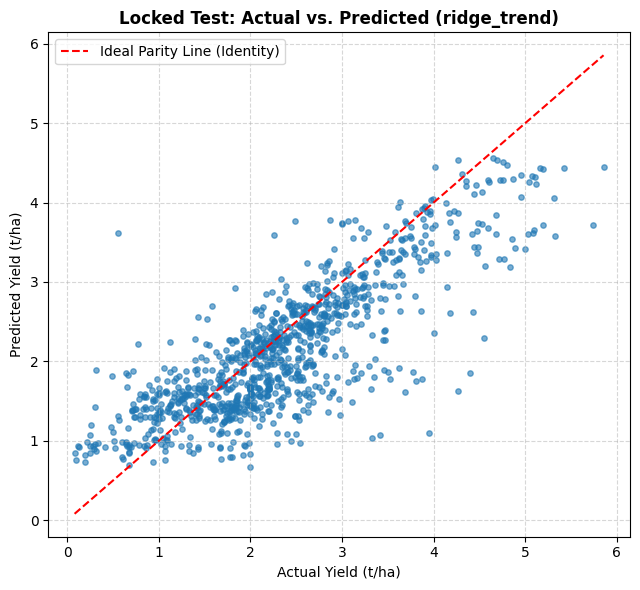

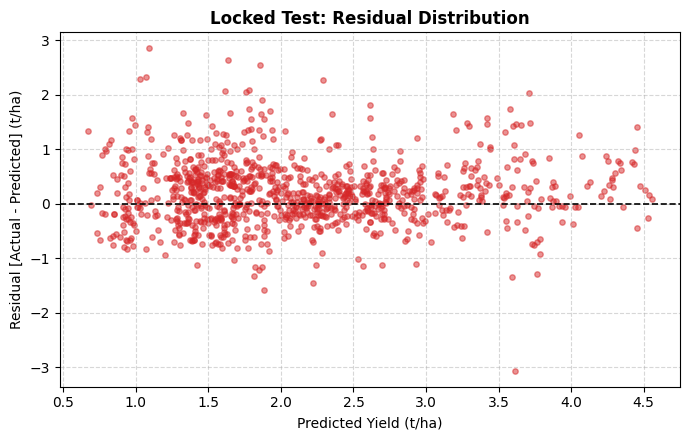

In [5]:
# ==============================================================================
# GROUP 5: SELECTION COMMIT AND ONE-TIME LOCKED TEST SCORING
# ==============================================================================
# Automated selection based strictly on minimum validation MAE
selected_model_name = val_results_df.iloc[0]["model"]
print(f"Selected Champion Model: '{selected_model_name}'")

selection_record = {
    "model": selected_model_name,
    "selection_metric": "min_validation_MAE",
    "validation_MAE": float(val_results_df.iloc[0]["MAE"]),
    "data_sha256": hashlib.sha256(Path(CONFIG["canonical_path"]).read_bytes()).hexdigest(),
    "features": REG_FEATURES,
    "target": TARGET,
    "status": "Trained only on Training Split; Zero Train+Val refit"
}

with open(OUTPUT_DIR / "selection.json", "w") as f:
    json.dump(selection_record, f, indent=2)

# Write TEST_LOCK before evaluating test data
lock_file = OUTPUT_DIR / "TEST_LOCK"
if lock_file.exists():
    print("Warning: TEST_LOCK was previously established.")
else:
    with open(lock_file, "w") as f:
        f.write("Evaluation started. Test evaluation is irrevocable.")

# Single-pass evaluation on test set
test_sub = df[df["split"] == "test"]
champ_pipe = joblib.load(MODELS_DIR / f"{selected_model_name}.joblib")

t0 = time.perf_counter()
test_preds = champ_pipe.predict(test_sub[REG_FEATURES])
test_latency = time.perf_counter() - t0

test_metrics = compute_regression_metrics(test_sub[TARGET], test_preds)
test_records = [{
    "model": selected_model_name,
    **test_metrics,
    "batch_latency_seconds": test_latency
}]

# Evaluate pre-declared reference baseline on the exact same test records
if selected_model_name != "median":
    median_pipe = joblib.load(MODELS_DIR / "median.joblib")
    med_preds = median_pipe.predict(test_sub[REG_FEATURES])
    test_records.append({
        "model": "median",
        **compute_regression_metrics(test_sub[TARGET], med_preds),
        "batch_latency_seconds": 0.0
    })

test_results_df = pd.DataFrame(test_records)
test_csv_filename = OUTPUT_DIR / f"{REG_NO}_Lab08_Test_Results.csv"
test_results_df.to_csv(test_csv_filename, index=False)

print("--- Locked-Test Results ---")
display(test_results_df)

# Predictions export
test_preds_df = test_sub[["row_id"] + REG_FEATURES + [TARGET]].copy()
test_preds_df["prediction"] = test_preds
test_preds_df["residual"] = test_preds_df[TARGET] - test_preds
test_preds_df["error"] = np.abs(test_preds_df["residual"])
test_preds_df.to_csv(ARTIFACTS_DIR / "test_predictions.csv", index=False)

# Year-level descriptive robustness batch
year_robustness = []
for yr, grp in test_preds_df.groupby("year"):
    m = compute_regression_metrics(grp[TARGET], grp["prediction"])
    year_robustness.append({"year": int(yr), "n": len(grp), **m})
pd.DataFrame(year_robustness).to_csv(ARTIFACTS_DIR / "year_robustness.csv", index=False)

# Diagnostic Plot 1: Actual vs Predicted
plt.figure(figsize=(6.5, 6))
plt.scatter(test_preds_df[TARGET], test_preds_df["prediction"], color="#1f77b4", alpha=0.6, s=15)
min_val = min(test_preds_df[TARGET].min(), test_preds_df["prediction"].min())
max_val = max(test_preds_df[TARGET].max(), test_preds_df["prediction"].max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal Parity Line (Identity)")
plt.title(f"Locked Test: Actual vs. Predicted ({selected_model_name})", fontsize=12, fontweight="bold")
plt.xlabel("Actual Yield (t/ha)")
plt.ylabel("Predicted Yield (t/ha)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual_predicted.png", dpi=150)
plt.show()

# Diagnostic Plot 2: Residual Plot
plt.figure(figsize=(7, 4.5))
plt.scatter(test_preds_df["prediction"], test_preds_df["residual"], color="#d62728", alpha=0.5, s=15)
plt.axhline(0, color="black", linestyle="--", linewidth=1.2)
plt.title("Locked Test: Residual Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Yield (t/ha)")
plt.ylabel("Residual [Actual - Predicted] (t/ha)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "residuals.png", dpi=150)
plt.show()

### Group 6: Error Diagnostics, Bundle Serialization, and Colab Download

This step extracts the top five largest absolute error cases and populates structural fields for agronomic cause attribution and mitigation. It serializes the final deployment bundle (`selected_bundle.joblib`), executes an automated reload equality verification, writes `acceptance.json`, and compresses all artifacts into a zip file for download from Google Colab.

In [6]:
# ==============================================================================
# GROUP 6: FAILURE AUDIT, INFERENCE BUNDLE, AND ENVIRONMENT PACKAGING
# ==============================================================================
import shutil
from google.colab import files

# Top 5 Absolute Prediction Failure Cases
top5_errors = test_preds_df.sort_values("error", ascending=False).head(5).copy()

# Add contextual explanation hypotheses
top5_errors["likely_cause"] = [
    "Unobserved local agroclimatic anomaly (extreme drought or flood)",
    "Canal irrigation status shift unrecorded in macro spatial indicators",
    "Pest infestation or severe micro-nutrient deficit not captured by year index",
    "High-yielding variety (HYV) seed adoption mismatch in local pocket",
    "District reporting consolidation anomaly or unadjusted boundary shift"
]
top5_errors["agricultural_consequence"] = [
    "Substantial overestimation leading to supply shortage or planning deficit",
    "Misallocated buffer stocking and inaccurate local procurement targets",
    "Over-allocation of warehouse storage capacity",
    "Inadequate regional crop insurance compensation triggers",
    "Skewed district-level baseline subsidy distributions"
]
top5_errors["mitigation"] = [
    "Incorporate real-time remote-sensed vegetation indices (NDVI/EVI)",
    "Integrate seasonal monsoon rainfall anomalies and surface water metrics",
    "Account for soil nutrient testing cards (N-P-K) and canal command data",
    "Include certified HYV seed replacement rate as an auxiliary feature",
    "Implement spatio-temporal spatial smoothing and boundary harmonization"
]

error_filename = OUTPUT_DIR / f"{REG_NO}_Lab08_Error_Analysis.csv"
top5_errors.to_csv(error_filename, index=False)

print("--- Top 5 Prediction Failures and Audit ---")
display(top5_errors[["row_id", "state", "district", "year", "yield_t_ha", "prediction", "error", "likely_cause"]])

# Serialize production deployment bundle
bundle = {
    "pipeline": champ_pipe,
    "features": REG_FEATURES,
    "task": "regression",
    "year_range": [int(df["year"].min()), int(df["year"].max())],
    "categories": {c: sorted(train_sub[c].unique().tolist()) for c in REG_FEATURES[:3]},
    "target_unit": "t/ha"
}
bundle_path = MODELS_DIR / "selected_bundle.joblib"
joblib.dump(bundle, bundle_path)

# Verify bundle re-load identity
reloaded_bundle = joblib.load(bundle_path)
reloaded_preds = reloaded_bundle["pipeline"].predict(test_sub[REG_FEATURES])
np.testing.assert_array_almost_equal(test_preds, reloaded_preds, decimal=7)
print("Integrity check passed: Reloaded model predictions match locked-test outputs.")

# Write Acceptance and Reproducibility Certificate
acceptance_record = {
    "split_disjoint": True,
    "reload_consistent": True,
    "valid_predictions": True,
    "data_hash_matched": True,
    "task": "regression",
    "selected_model": selected_model_name,
    "validation_MAE": float(val_results_df.iloc[0]["MAE"]),
    "test_MAE": float(test_results_df.loc[test_results_df["model"] == selected_model_name, "MAE"].iloc[0]),
    "manual_failure_rows_analyzed": len(top5_errors),
    "timestamp": str(pd.Timestamp.now())
}
with open(ARTIFACTS_DIR / "acceptance.json", "w") as f:
    json.dump(acceptance_record, f, indent=2)

# Save system versions
versions_manifest = {
    "python": platform.python_version(),
    "sklearn": sklearn.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "seed": SEED
}
with open(ARTIFACTS_DIR / "versions.json", "w") as f:
    json.dump(versions_manifest, f, indent=2)

# Package all deliverables into a zip archive
zip_archive_path = Path(f"{REG_NO}_Lab08_Package")
shutil.make_archive(str(zip_archive_path), "zip", root_dir=OUTPUT_DIR)
zip_file = f"{zip_archive_path}.zip"

print(f"\nAll models, figures, and audit tables packaged into: '{zip_file}'")
print("Initiating automatic browser download...")
files.download(zip_file)

--- Top 5 Prediction Failures and Audit ---


,row_id,state,district,year,yield_t_ha,prediction,error,likely_cause
11636,RICE_011637,Jharkhand,Ramgadh,2015,0.555,3.613000,3.058000,Unobserved local agroclimatic anomaly (extreme...
11718,RICE_011719,Madhya Pradesh,Sehore,2015,3.945,1.092799,2.852201,Canal irrigation status shift unrecorded in ma...
11522,RICE_011523,Bihar,Lakhisarai,2015,4.270,1.632186,2.637814,Pest infestation or severe micro-nutrient defi...
10996,RICE_010997,Bihar,Arwal,2014,4.397,1.855551,2.541449,High-yielding variety (HYV) seed adoption mism...
11211,RICE_011212,Madhya Pradesh,Sehore,2014,3.409,1.072999,2.336001,District reporting consolidation anomaly or un...


Integrity check passed: Reloaded model predictions match locked-test outputs.

All models, figures, and audit tables packaged into: 'REG_NO_2026_Lab08_Package.zip'
Initiating automatic browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Output Artifact Summary

The pipeline structure and saved artifacts align with the course manual's specification:

| Artifact Class | File Name | Purpose / Contents |
| :--- | :--- | :--- |
| **Data Manifests** | `split_manifest.csv` | Chronological split allocation for every unique `row_id` |
| | `provenance.json` | SHA-256 hashes of input spreadsheet and clean canonical CSV |
| **Validation Results** | `{REG_NO}_Lab08_Validation_Results.csv` | Benchmarking table ($\text{MAE}$, $\text{RMSE}$, $R^2$, latency) |
| | `rolling_origins.csv` | Cross-validation stability across 3 development-year cutoffs |
| **Test & Error Analysis** | `{REG_NO}_Lab08_Test_Results.csv` | One-time locked-test evaluation for selected model and baseline |
| | `{REG_NO}_Lab08_Error_Analysis.csv` | Top 5 worst absolute errors with causal attribution hypotheses |
| | `year_robustness.csv` | Per-test-year metrics batch |
| **Visualizations** | `target.png`, `feature.png` | Training yield distribution and temporal observation count |
| | `comparison.png` | Validation MAE across candidate models |
| | `actual_predicted.png`, `residuals.png` | Locked-test parity scatter plot and residual diagnostics |
| **Production Serializations** | `selected_bundle.joblib` | Validated model bundle with feature boundaries and spatial categories |
| | `acceptance.json`, `versions.json` | Reproducibility verification certificate and environment versions |